/pscratch/sd/a/adematti/fits_systematic_templates/abacus-hf-dr2-v2-altmtl/cosmo-base_ELG2-S2-w-auw-ebafeffe/samples_1.h5
Removed no burn in
Removed no burn in


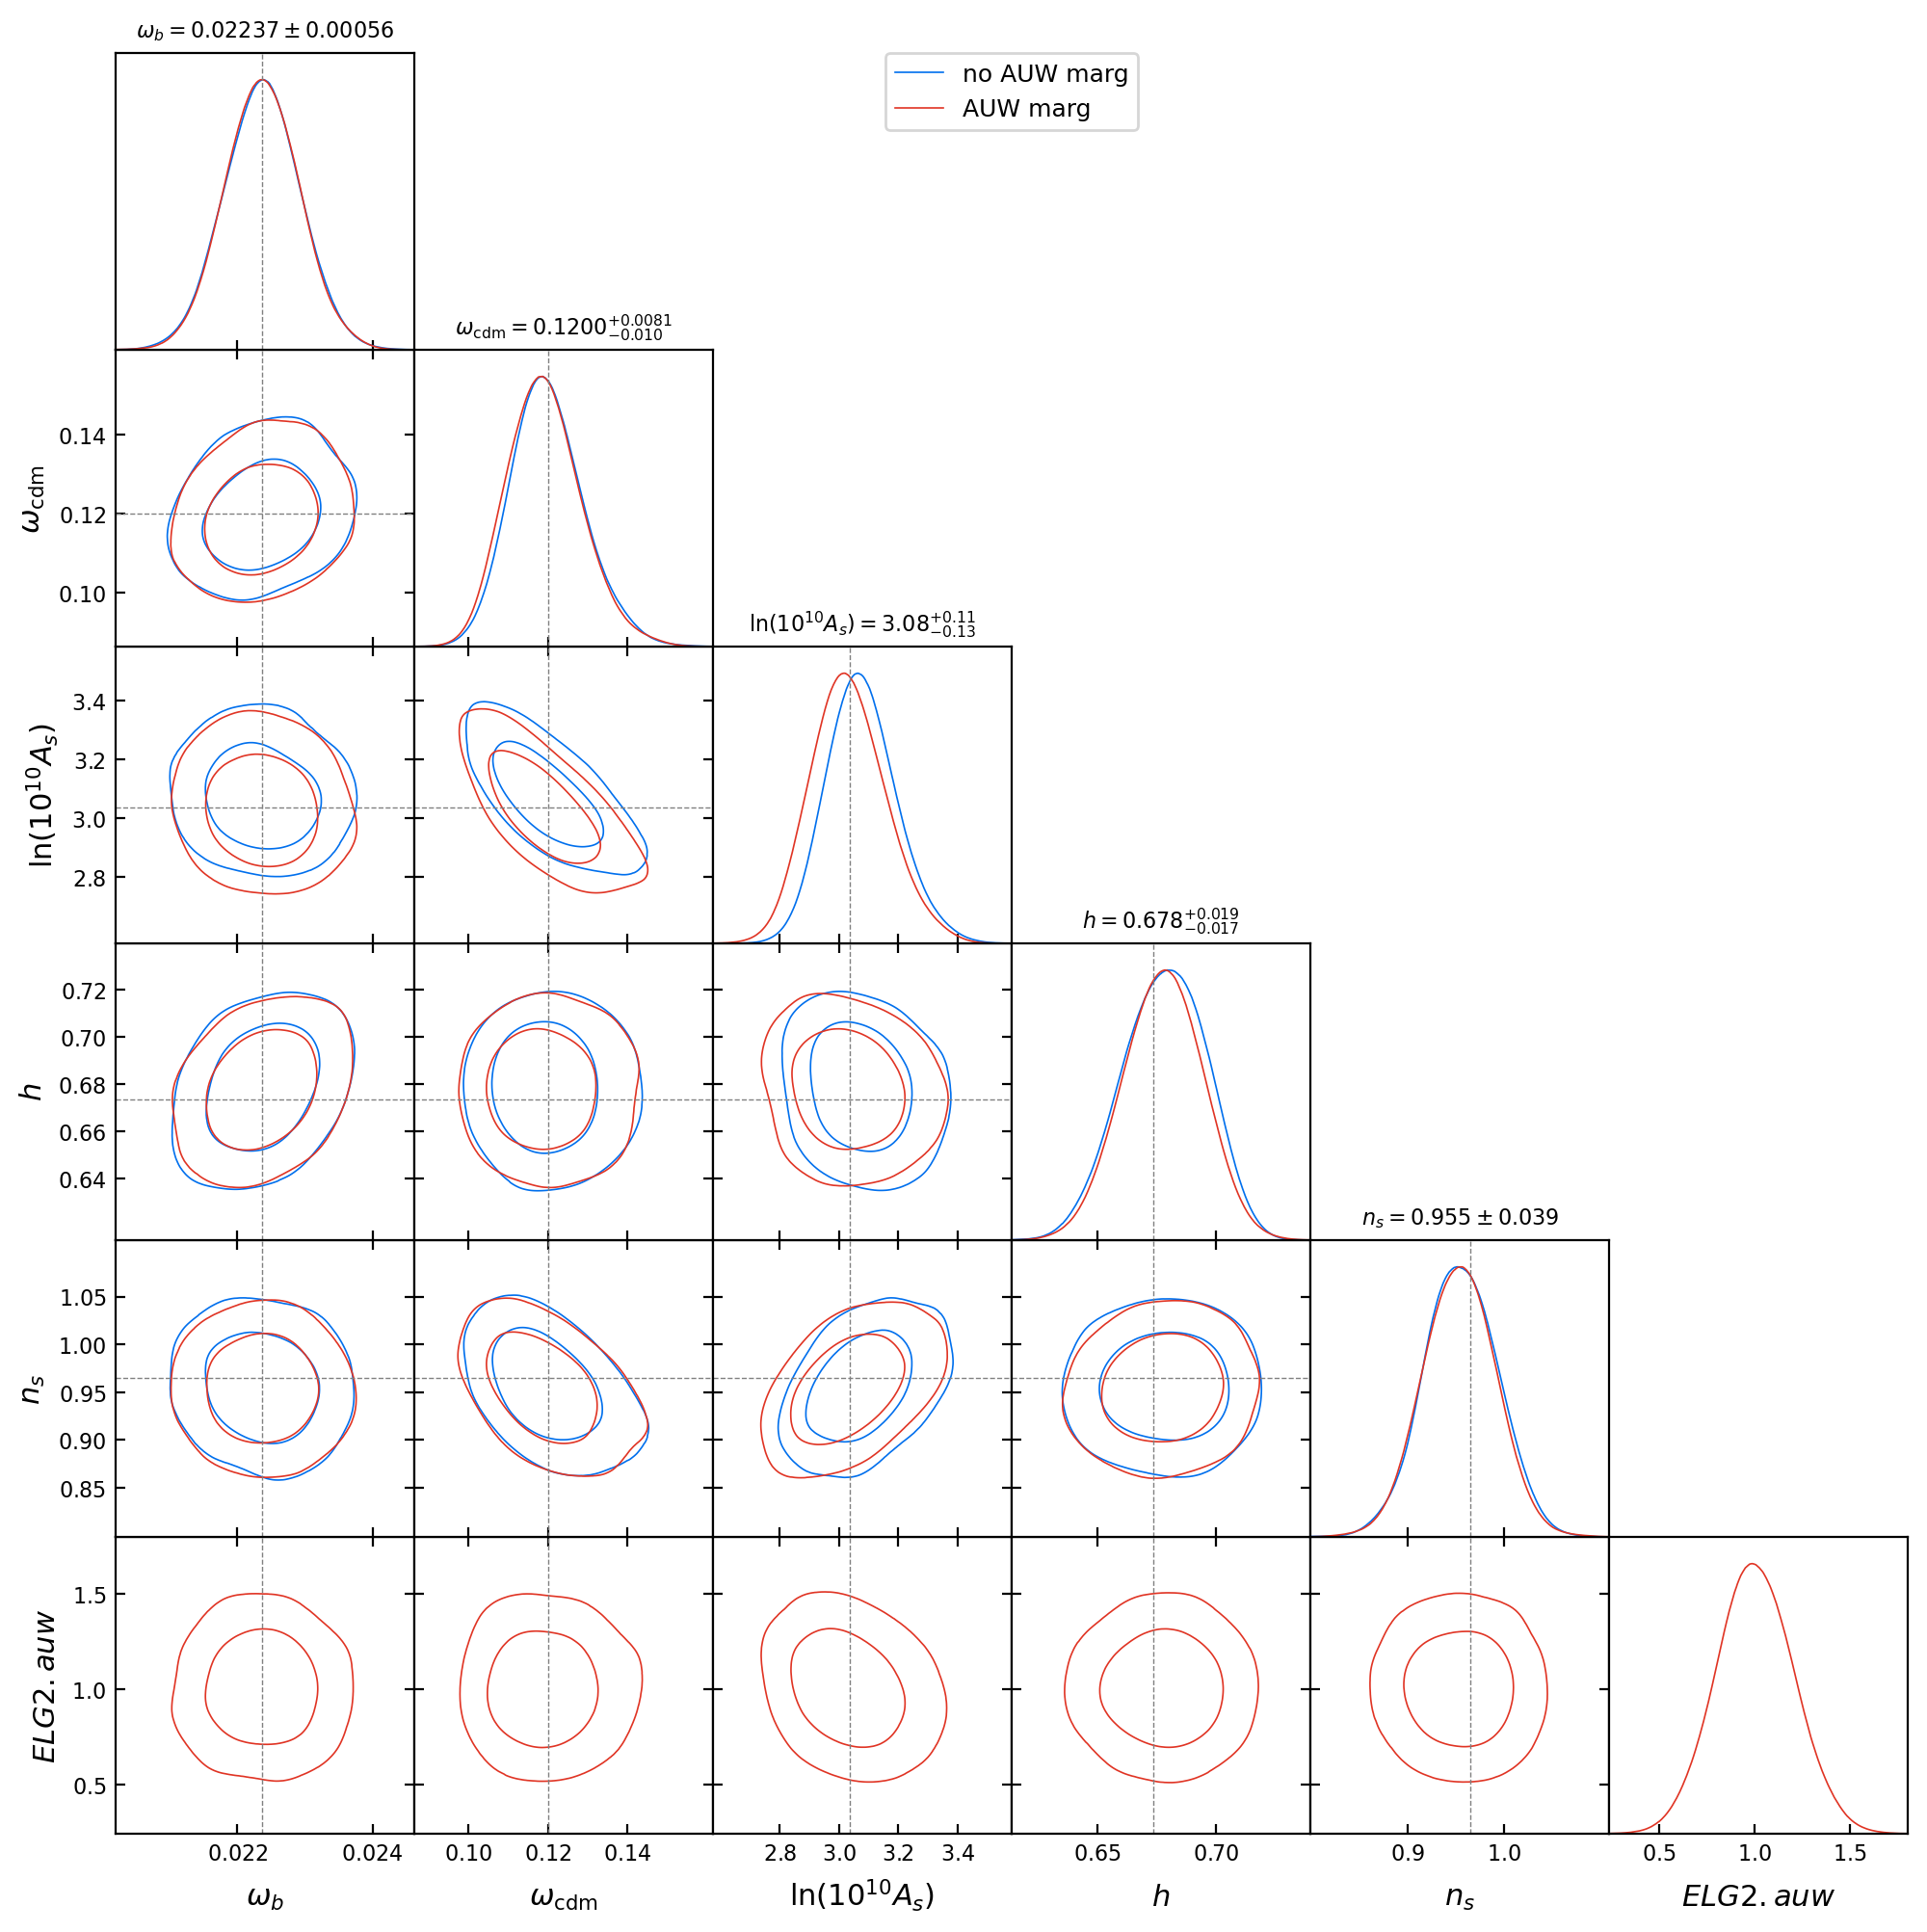

In [10]:
import sys

from pathlib import Path
import matplotlib.pyplot as plt

from desilike.samples import MCSamples, Profiles, plotting
from cosmoprimo.fiducial import AbacusSummit

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

params_toplot = ['omega_b', 'omega_cdm', 'logA', 'h', 'n_s', 'ELG2.b1p', 'ELG2.b2p', 'ELG2.bsp', 'ELG2.auw']

cosmo = AbacusSummit()
truth = {}
for p in params_toplot:
    try:
        truth[p] = cosmo[p]
    except:
        continue


def read_samples(fn, burnin=False, thin=False):
    if isinstance(fn, list):
        samples = MCSamples.concatenate([MCSamples.read(fn).remove_burnin(burnin if burnin else 0.) for fn in fn])
    else:
        samples = MCSamples.read(fn)
    if thin:
        samples = samples[::thin]
    return samples

dirname = Path('/pscratch/sd/a/adematti/fits_systematic_templates/abacus-hf-dr2-v2-altmtl/')
samples, legends = [], []
samples.append(read_samples([dirname / f'cosmo-base_ELG2-S2-21e7c046/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('no AUW marg')
print(dirname / f'cosmo-base_ELG2-S2-w-auw-ebafeffe/samples_1.h5')
samples.append(read_samples([dirname / f'cosmo-base_ELG2-S2-w-auw-ebafeffe/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('AUW marg')

plotting.plot_triangle(samples, params=params_toplot, title_limit=1, markers=truth, legend_labels=legends)
plt.show()